# Práctica 2. CNN para clasificación
### Redes Neuronales Artificiales y Aprendizaje Profundo
**José Luis Haro Díaz**

In [ ]:
import os
import random
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from keras.layers import BatchNormalization, Dropout
from keras.layers import RandomFlip, RandomRotation, RandomZoom
import matplotlib.pyplot as plt
import cv2
import zipfile
from keras.callbacks import EarlyStopping

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"joseluisharodiaz","key":"1258694cc78ab7c51d386d632048e900"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:07<00:00, 151MB/s]



In [ ]:
with zipfile.ZipFile("dogsvscats.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [ ]:
train_ds = keras.utils.image_dataset_from_directory(
    directory='data/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(224,224)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory='data/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(224,224)
)

#Normalización
def process(image, label):
    image = tf.cast(image / 255., tf.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [ ]:
data_augmentation = keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

In [ ]:
model = Sequential()

model.add(data_augmentation)

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

In [ ]:
history = model.fit(train_ds, epochs=20, validation_data=validation_ds, callbacks=[early_stop])

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.6605 - loss: 0.6664 - val_accuracy: 0.7246 - val_loss: 0.5340
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 130ms/step - accuracy: 0.7207 - loss: 0.5463 - val_accuracy: 0.7726 - val_loss: 0.4710
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 129ms/step - accuracy: 0.7431 - loss: 0.5141 - val_accuracy: 0.7848 - val_loss: 0.4480
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 131ms/step - accuracy: 0.7632 - loss: 0.4891 - val_accuracy: 0.7866 - val_loss: 0.4466
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 137ms/step - accuracy: 0.7773 - loss: 0.4716 - val_accuracy: 0.8176 - val_loss: 0.4051
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 137ms/step - accuracy: 0.7860 - loss: 0.4567 - val_accuracy: 0.8066 - val_loss: 0.4108
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 137ms/step - accuracy: 0.7972 - loss: 0.4442 - val_accuracy: 0.8260 - val_loss: 0.3789
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 137ms/step - accuracy: 0.8081 - loss: 0

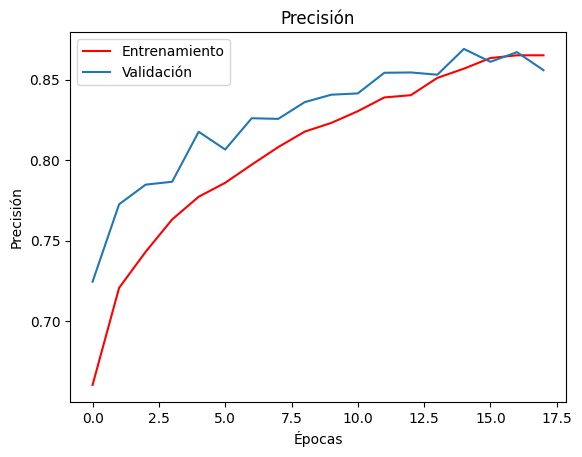

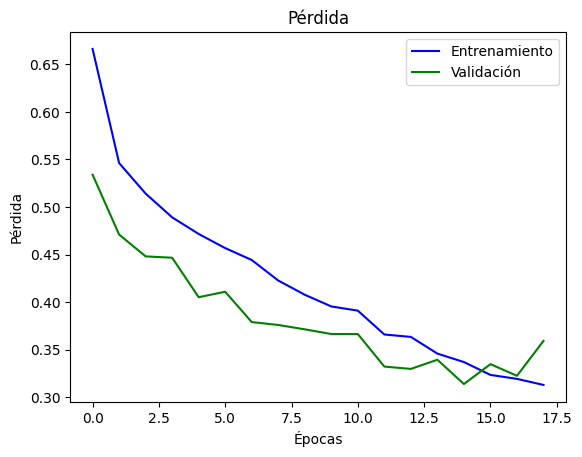

In [ ]:
plt.plot(history.history['accuracy'], color='red', label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()

plt.plot(history.history['loss'], color='blue', label='Entrenamiento')
plt.plot(history.history['val_loss'], color='green', label='Validación')
plt.title('Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

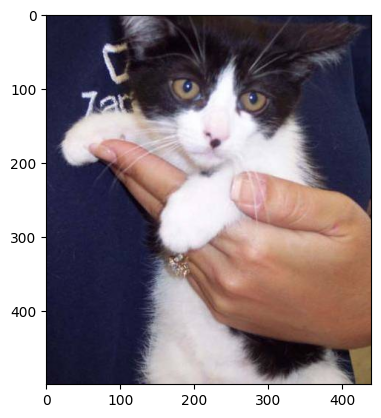

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicción: Gato
Real: Gato
////////////////////////////////////////////////////////////////////////////////////////////////////


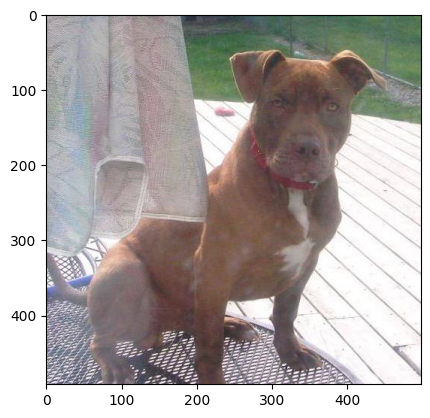

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicción: Perro
Real: Perro
////////////////////////////////////////////////////////////////////////////////////////////////////


In [ ]:
#Selección random de las imagenes para su predicción
path_dog = '/content/data/test/dogs'
path_cat = '/content/data/test/cats'

all_images = []

for img in os.listdir(path_dog):
    all_images.append((f'{path_dog}/{img}', 'Perro'))

for img in os.listdir(path_cat):
    all_images.append((f'{path_cat}/{img}', 'Gato'))

random_imgs = random.sample(all_images, 2)

def predecir(img):
    img = cv2.resize(img, (224,224))
    img = img / 255.0
    img = img.reshape((1,224,224,3))
    pred = model.predict(img)
    return "Perro" if pred > 0.5 else "Gato"

for ruta, etiqueta_real in random_imgs:
    img = cv2.imread(ruta)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.show()

    pred = predecir(img)

    print(f"Predicción: {pred}")
    print(f"Real: {etiqueta_real}")
    print("/"*100)